# Day 9: EfficientNetV2 + CBAM Evaluation

## Objective

Evaluate the trained EfficientNetV2 + CBAM model on the untouched test dataset and compare its performance against the EfficientNetV2 baseline.

### Goals

- Load the trained model
- Evaluate test loss and accuracy
- Generate predictions
- Compute classification metrics
- Visualize confusion matrix
- Analyze prediction distribution
- Visualize misclassified MRI images
- Compare Baseline vs CBAM

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

print("Project Root:", PROJECT_ROOT)

Project Root: g:\Projects\Dementia_Detection_Model


In [2]:
from pathlib import Path

import pandas as pd

from src.config.model_config import (
    BASELINE_MODEL_SAVE_PATH,
    CBAM_MODEL_SAVE_PATH,
)

from src.evaluation.evaluate import run_evaluation

In [7]:
import json

with open("outputs/evaluation/baseline/metrics.json") as f:
    baseline_metrics = json.load(f)

with open("outputs/evaluation/cbam/metrics.json") as f:
    cbam_metrics = json.load(f)

In [9]:
comparison = pd.DataFrame(
    {
        "Metric": [
            "Test Loss",
            "Test Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
        ],
        "Baseline": [
            baseline_metrics["test_loss"],
            baseline_metrics["test_accuracy"],
            baseline_metrics["accuracy"],
            baseline_metrics["accuracy"],
            baseline_metrics["accuracy"],
        ],
        "CBAM": [
            cbam_metrics["test_loss"],
            cbam_metrics["test_accuracy"],
            cbam_metrics["accuracy"],
            cbam_metrics["accuracy"],
            cbam_metrics["accuracy"],
        ],
    }
)

comparison

,Metric,Baseline,CBAM
0,Test Loss,0.76287,0.346303
1,Test Accuracy,0.69175,0.856750
2,Precision,0.69175,0.856750
3,Recall,0.69175,0.856750
4,F1-Score,0.69175,0.856750


In [10]:
from tensorflow.keras.models import load_model

from src.models.cbam import (
    CBAM,
    ChannelAttention,
    SpatialAttention,
)

In [11]:
baseline_model = load_model(
    BASELINE_MODEL_SAVE_PATH
)

cbam_model = load_model(
    CBAM_MODEL_SAVE_PATH,
    custom_objects={
        "CBAM": CBAM,
        "ChannelAttention": ChannelAttention,
        "SpatialAttention": SpatialAttention,
    },
)

g:\Projects\DementiaDetection\venv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'cbam', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [12]:
parameter_comparison = pd.DataFrame(
    {
        "Model": [
            "EfficientNetV2",
            "EfficientNetV2 + CBAM",
        ],
        "Total Parameters": [
            baseline_model.count_params(),
            cbam_model.count_params(),
        ],
    }
)

parameter_comparison

,Model,Total Parameters
0,EfficientNetV2,5924436
1,EfficientNetV2 + CBAM,6130694


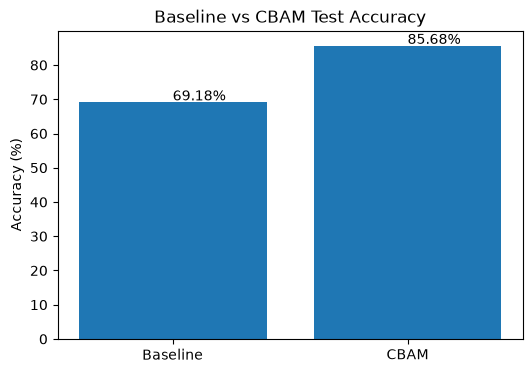

In [13]:
import matplotlib.pyplot as plt

models = ["Baseline", "CBAM"]
accuracy = [69.18, 85.68]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Baseline vs CBAM Test Accuracy")

for i, value in enumerate(accuracy):
    plt.text(i, value + 0.5, f"{value:.2f}%")

plt.show()

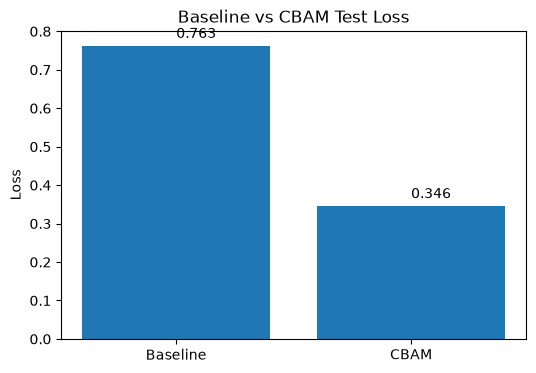

In [14]:
models = ["Baseline", "CBAM"]
loss = [
    baseline_metrics["test_loss"],
    cbam_metrics["test_loss"],
]

plt.figure(figsize=(6,4))
plt.bar(models, loss)

plt.ylabel("Loss")
plt.title("Baseline vs CBAM Test Loss")

for i, value in enumerate(loss):
    plt.text(i, value + 0.02, f"{value:.3f}")

plt.show()

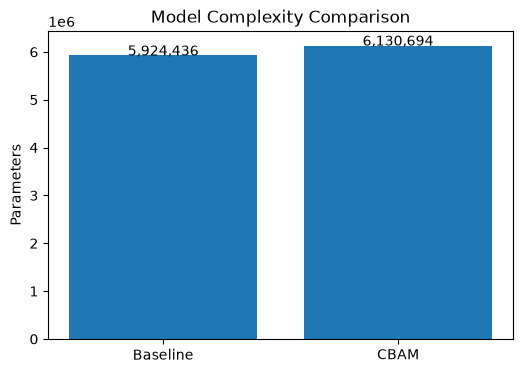

In [15]:
baseline_params = baseline_model.count_params()
cbam_params = cbam_model.count_params()

plt.figure(figsize=(6,4))

plt.bar(
    ["Baseline", "CBAM"],
    [baseline_params, cbam_params],
)

plt.ylabel("Parameters")
plt.title("Model Complexity Comparison")

for i, value in enumerate([baseline_params, cbam_params]):
    plt.text(i, value, f"{value:,}", ha="center")

plt.show()

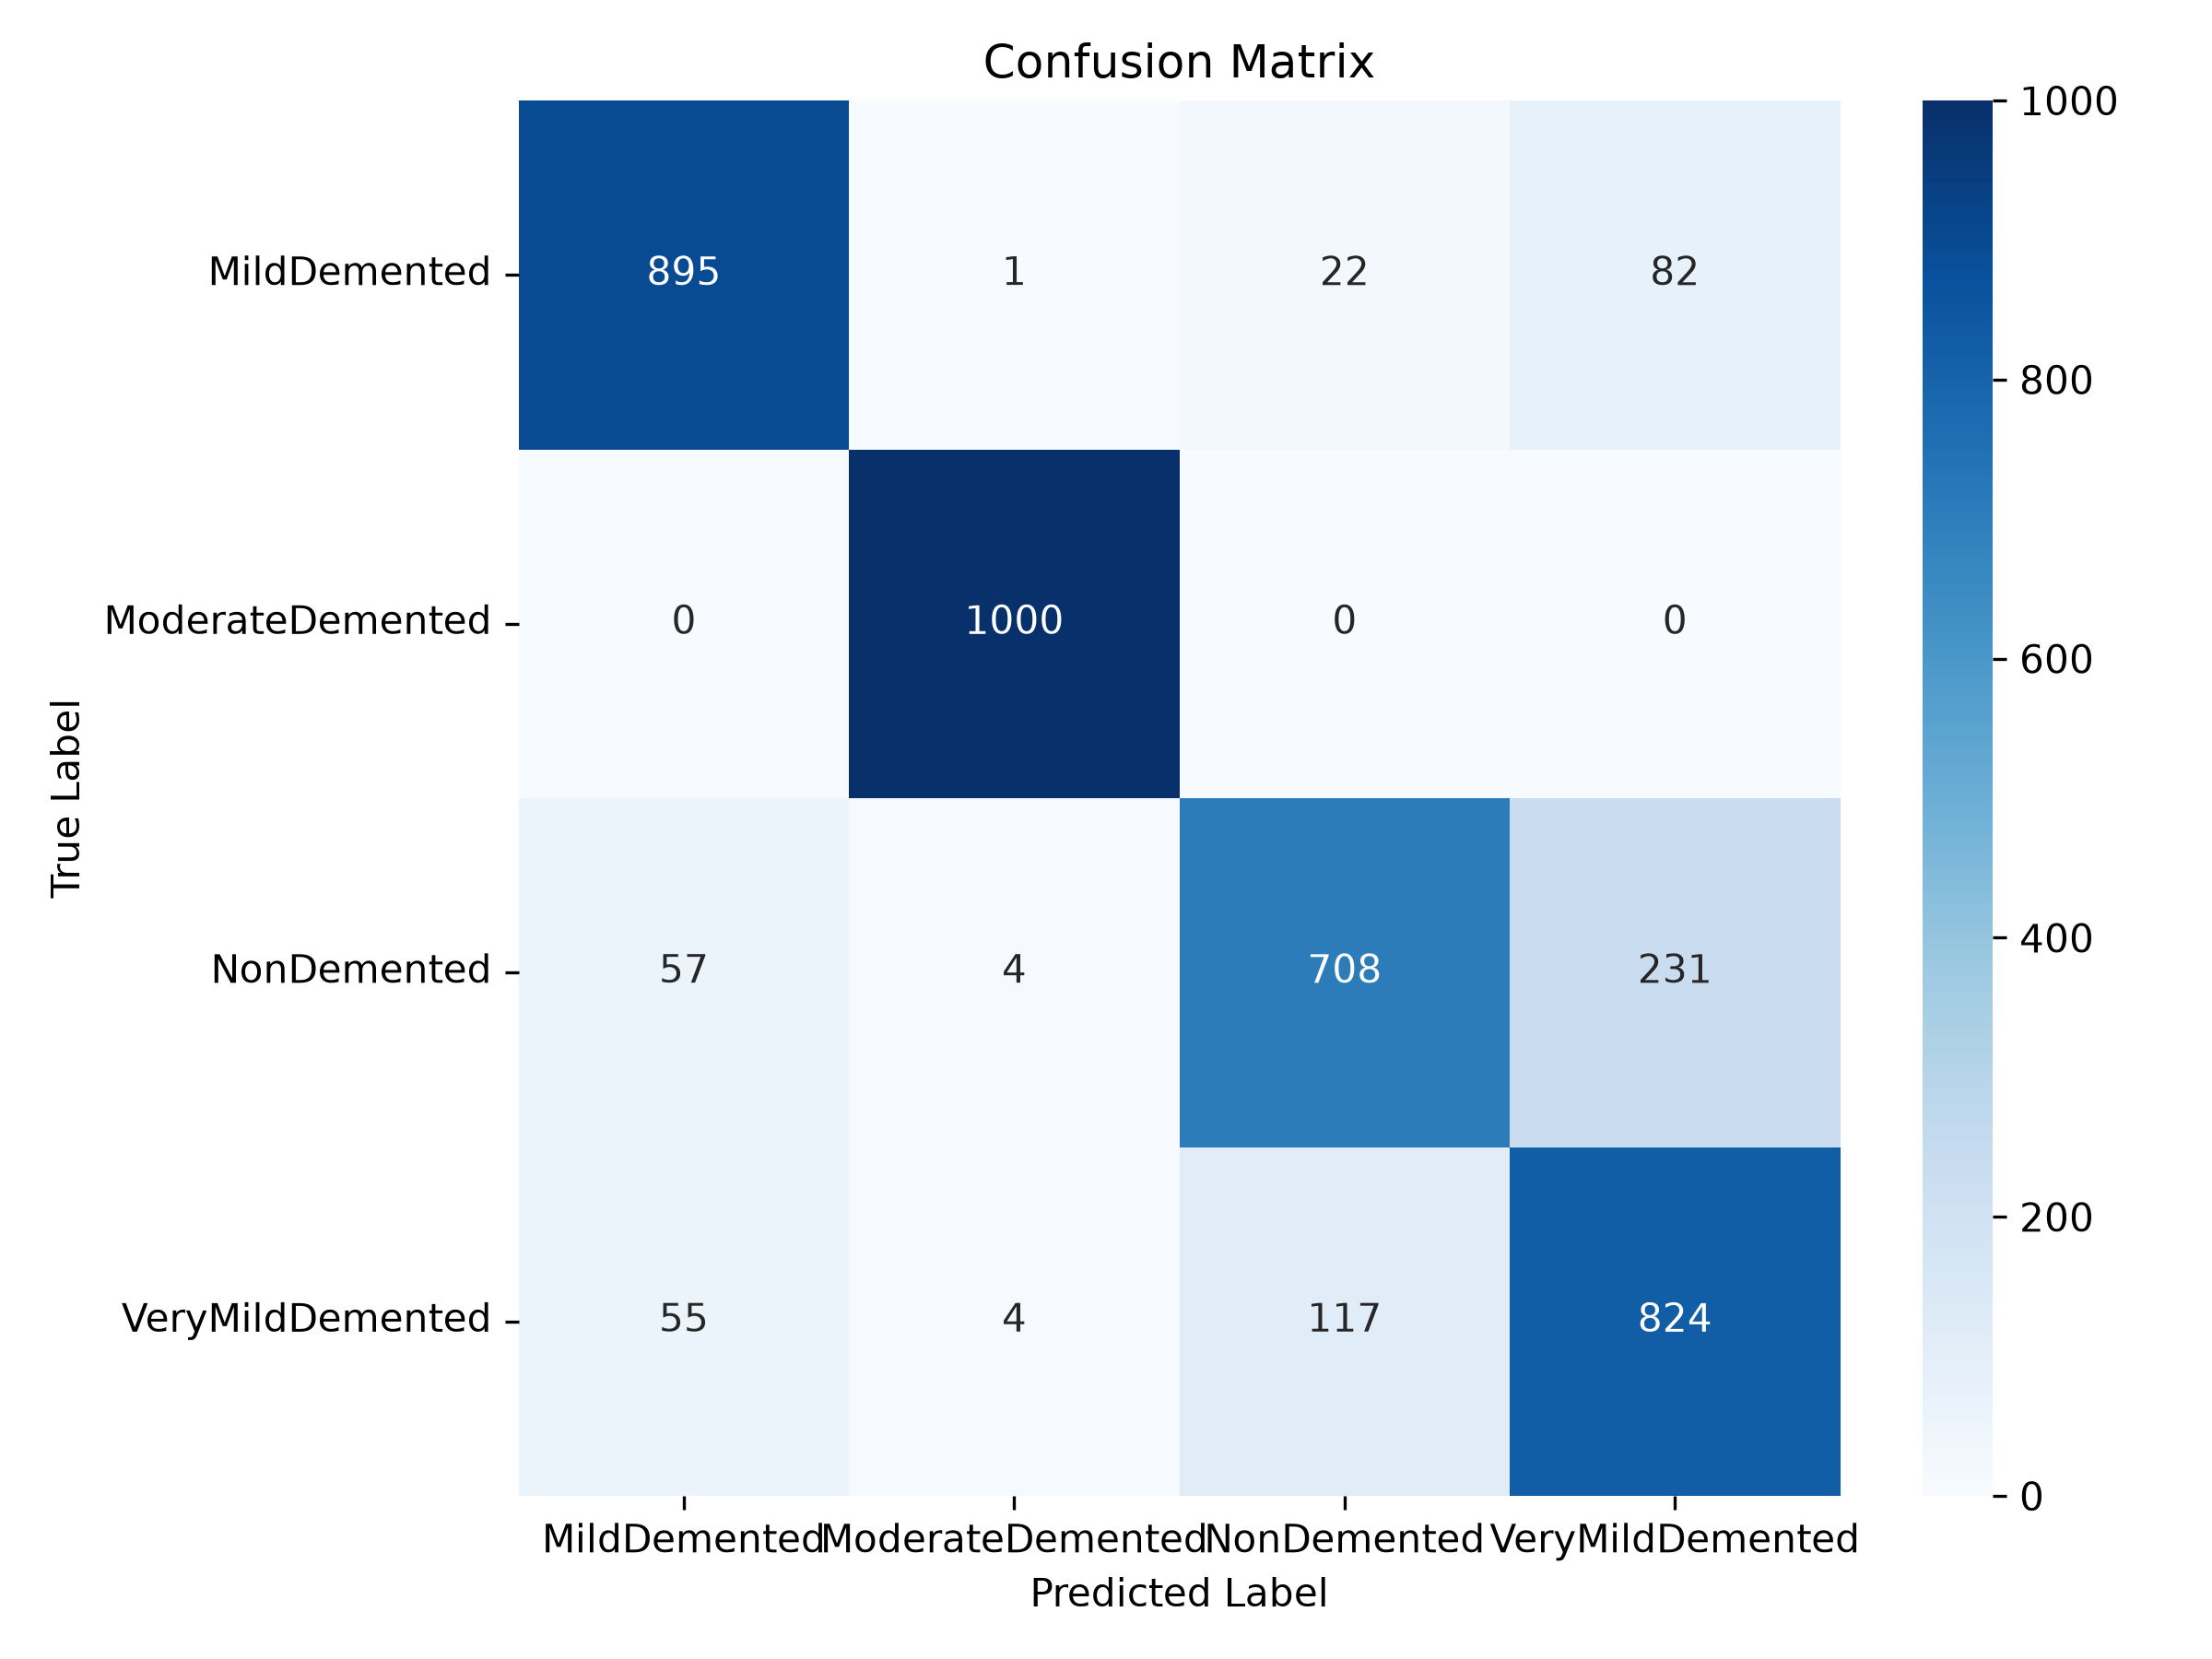

In [3]:
from pathlib import Path
from IPython.display import Image, display

display(
    Image(
        filename=Path("outputs/evaluation/cbam/confusion_matrix.png")
    )
)